# PyTorch Reference Guide

This notebook is your **single reference for all core PyTorch concepts**, written from the ground up for beginners.

---
<a id='section-0'></a>
## Section 0 — Environment Setup & Verification

Before anything else, we need to confirm that PyTorch is installed correctly and that we know which hardware accelerator is available on this machine.

**What we are checking:**
- `torch.__version__` — the PyTorch version installed
- `torch.backends.mps.is_available()` — is Apple Silicon (M1/M2/M3) GPU available?
- `torch.cuda.is_available()` — is an NVIDIA GPU available?

We then pick the best available `device`. All tensors and models should be moved to this device.

In [38]:
# Cell 1: Import PyTorch & core libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import os, time, platform

print('All imports successful!')

All imports successful!


In [39]:
# Cell 2: Verify environment & select the best available device
print('=' * 50)
print(f'  PyTorch Version  : {torch.__version__}')
print(f'  Python Version   : {__import__("sys").version.split()[0]}')
print('-' * 50)
print(f'  CUDA available   : {torch.cuda.is_available()}')
print(f'  MPS  available   : {torch.backends.mps.is_available()}')
print('=' * 50)

# Pick the best device automatically
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f'\n  Active Device : {DEVICE}')
print('=' * 50)

  PyTorch Version  : 2.6.0
  Python Version   : 3.9.6
--------------------------------------------------
  CUDA available   : False
  MPS  available   : True

  Active Device : mps


---
<a id='section-1'></a>
## Section 1 — Tensors

A **tensor** is the fundamental data structure in PyTorch — think of it as a supercharged NumPy array that can live on a GPU.

| Dimension | What it represents | Example shape |
|---|---|---|
| 0D (scalar) | A single number | `torch.tensor(3.14)` |
| 1D (vector) | A list of numbers | `shape: [5]` |
| 2D (matrix) | A table of numbers | `shape: [3, 4]` |
| 3D | A stack of matrices | `shape: [batch, rows, cols]` |
| 4D | Image batches | `shape: [batch, channels, H, W]` |

### 1.1 — Tensor Creation

- `torch.tensor(data)` — from Python lists or NumPy arrays
- `torch.zeros(shape)` — filled with 0s
- `torch.ones(shape)` — filled with 1s
- `torch.rand(shape)` — uniform random values in [0, 1)
- `torch.randn(shape)` — standard normal distribution
- `torch.arange(start, end, step)` — like Python's `range()`
- `torch.from_numpy(array)` — shares memory with a NumPy array

In [40]:
# Tensor Creation Methods
t_list  = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])
t_zeros = torch.zeros(2, 3)
t_ones  = torch.ones(2, 3)
t_rand  = torch.rand(3, 3)
t_randn = torch.randn(3, 3)
t_range = torch.arange(0, 10, 2)

np_arr  = np.array([10, 20, 30])
t_numpy = torch.from_numpy(np_arr)

print(f'From list        : {t_list}')
print(f'Zeros (2x3):\n{t_zeros}')
print(f'Ones  (2x3):\n{t_ones}')
print(f'Random uniform:\n{t_rand}')
print(f'Arange (0,10,2)  : {t_range}')
print(f'From NumPy       : {t_numpy}')

From list        : tensor([1., 2., 3., 4., 5.])
Zeros (2x3):
tensor([[0., 0., 0.],
        [0., 0., 0.]])
Ones  (2x3):
tensor([[1., 1., 1.],
        [1., 1., 1.]])
Random uniform:
tensor([[0.0457, 0.2097, 0.5387],
        [0.2962, 0.6980, 0.6653],
        [0.3120, 0.2272, 0.4531]])
Arange (0,10,2)  : tensor([0, 2, 4, 6, 8])
From NumPy       : tensor([10, 20, 30])


### 1.2 — Shapes, Dimensions & Reshaping

Understanding tensor shapes is critical. Three attributes you will use constantly:
- `.shape` — the dimensions (e.g., `torch.Size([3, 4])`)
- `.ndim` — number of dimensions
- `.numel()` — total number of elements

**Reshaping operations:**
- `.reshape(new_shape)` — new shape (may copy data)
- `.squeeze()` — removes dimensions of size 1
- `.unsqueeze(dim)` — adds a dimension of size 1
- `.permute(dims)` — reorder dimensions (used heavily with images)

In [41]:
# Shape Operations
x = torch.randn(4, 5)
print(f'Original shape  : {x.shape}')
print(f'ndim            : {x.ndim}')
print(f'numel()         : {x.numel()}   (4 x 5 = 20)')

x_reshaped = x.reshape(2, 10)
x_flat     = x.reshape(-1)         # -1 = infer the dimension
print(f'reshaped (2,10) : {x_reshaped.shape}')
print(f'flattened (-1)  : {x_flat.shape}')

t = torch.zeros(1, 3, 1, 5)
print(f'\nBefore squeeze  : {t.shape}')
print(f'After squeeze   : {t.squeeze().shape}')

v = torch.randn(3)
print(f'\nBefore unsqueeze: {v.shape}')
print(f'unsqueeze(0)    : {v.unsqueeze(0).shape}  <- adds batch dim')
print(f'unsqueeze(1)    : {v.unsqueeze(1).shape}  <- adds column dim')

# permute: channels-first (PyTorch) to channels-last (matplotlib)
img     = torch.randn(3, 64, 64)   # [C, H, W]
img_hwc = img.permute(1, 2, 0)     # [H, W, C]
print(f'\nImage permute   : {img.shape} -> {img_hwc.shape}')

Original shape  : torch.Size([4, 5])
ndim            : 2
numel()         : 20   (4 x 5 = 20)
reshaped (2,10) : torch.Size([2, 10])
flattened (-1)  : torch.Size([20])

Before squeeze  : torch.Size([1, 3, 1, 5])
After squeeze   : torch.Size([3, 5])

Before unsqueeze: torch.Size([3])
unsqueeze(0)    : torch.Size([1, 3])  <- adds batch dim
unsqueeze(1)    : torch.Size([3, 1])  <- adds column dim

Image permute   : torch.Size([3, 64, 64]) -> torch.Size([64, 64, 3])


### 1.3 — Data Types (dtypes)

| dtype | Bits | Use case |
|---|---|---|
| `torch.float32` | 32 | Default for neural network weights |
| `torch.float64` | 64 | Scientific computing |
| `torch.float16` | 16 | Mixed-precision training (faster on GPU) |
| `torch.int64` | 64 | Class labels, indices |
| `torch.bool` | 1 | Masks, conditions |

> **Rule of thumb:** Use `float32` for model weights and activations, `int64` for class labels.

In [42]:
# Data Types
t_float = torch.tensor([1.0, 2.0, 3.0])      # float32 by default
t_int   = torch.tensor([1, 2, 3])             # int64 by default
t_bool  = torch.tensor([True, False, True])

print(f'Float tensor dtype : {t_float.dtype}')
print(f'Int   tensor dtype : {t_int.dtype}')
print(f'Bool  tensor dtype : {t_bool.dtype}')

# Explicit dtype
t_f16 = torch.ones(3, 3, dtype=torch.float16)
print(f'\nfloat16 tensor : {t_f16.dtype}  | shape: {t_f16.shape}')

# Type casting
t_casted = t_int.to(torch.float32)
t_long   = t_float.long()
print(f'\nint->float32 : {t_casted.dtype}')
print(f'float->int64 : {t_long.dtype}')

# Memory usage comparison
big = torch.randn(1000, 1000)
print(f'\nfloat32 size : {big.element_size() * big.numel() / 1e6:.2f} MB')
print(f'float16 size : {big.half().element_size() * big.numel() / 1e6:.2f} MB')

Float tensor dtype : torch.float32
Int   tensor dtype : torch.int64
Bool  tensor dtype : torch.bool

float16 tensor : torch.float16  | shape: torch.Size([3, 3])

int->float32 : torch.float32
float->int64 : torch.int64

float32 size : 4.00 MB
float16 size : 2.00 MB


### 1.4 — Tensor Operations

PyTorch supports all standard math operations. They work element-wise by default.

- Arithmetic: `+`, `-`, `*`, `/` (element-wise)
- Matrix multiplication: `@` or `torch.matmul()`
- Aggregation: `.sum()`, `.mean()`, `.max()`, `.min()`

**Broadcasting:** Smaller tensors are automatically expanded to match larger ones (NumPy-style).

In [43]:
# Tensor Operations
a = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
b = torch.tensor([[5.0, 6.0], [7.0, 8.0]])

print('a + b (element-wise):\n', a + b)
print('a * b (element-wise):\n', a * b)    # NOT matrix multiply!
print('a @ b (matrix mul):\n',   a @ b)

print(f'\na.sum()       = {a.sum():.1f}')
print(f'a.sum(dim=0)  = {a.sum(dim=0)}  <- sum each column')
print(f'a.sum(dim=1)  = {a.sum(dim=1)}  <- sum each row')
print(f'a.mean()      = {a.mean():.1f}')

# Broadcasting
print(f'\na + 10:\n{a + 10}')                         # scalar broadcast
row = torch.tensor([100.0, 200.0])
print(f'a + [100,200]:\n{a + row}')                   # row vector broadcast

a + b (element-wise):
 tensor([[ 6.,  8.],
        [10., 12.]])
a * b (element-wise):
 tensor([[ 5., 12.],
        [21., 32.]])
a @ b (matrix mul):
 tensor([[19., 22.],
        [43., 50.]])

a.sum()       = 10.0
a.sum(dim=0)  = tensor([4., 6.])  <- sum each column
a.sum(dim=1)  = tensor([3., 7.])  <- sum each row
a.mean()      = 2.5

a + 10:
tensor([[11., 12.],
        [13., 14.]])
a + [100,200]:
tensor([[101., 202.],
        [103., 204.]])


### 1.5 — Moving Tensors Between CPU and GPU

By default, all tensors are created on the **CPU**. To accelerate computation, move them to a GPU.

- **CUDA (NVIDIA):** `device = torch.device('cuda')`
- **MPS (Apple Silicon):** `device = torch.device('mps')`
- **CPU fallback:** `device = torch.device('cpu')`

> **Golden rule:** You can only operate on tensors that are on the **same device**. Mixing CPU and GPU tensors raises an error.

In [44]:
# Moving Between CPU & GPU
cpu_tensor = torch.randn(3, 3)
print(f'Created on : {cpu_tensor.device}')

# Move to best available device
gpu_tensor = cpu_tensor.to(DEVICE)
print(f'Moved to   : {gpu_tensor.device}')

# Create directly on device
direct = torch.ones(3, 3, device=DEVICE)
print(f'Created on : {direct.device}')

# Operation on device
result = gpu_tensor + direct
print(f'Result on  : {result.device}')

# Back to CPU for NumPy conversion
back_on_cpu  = result.cpu()
numpy_array  = back_on_cpu.numpy()
print(f'Back on    : {back_on_cpu.device}')
print(f'As NumPy   :\n{numpy_array}')

# Common mistake (commented out to avoid error):
# x_cpu + x_gpu  <- RuntimeError: Expected all tensors to be on the same device

Created on : cpu
Moved to   : mps:0
Created on : mps:0
Result on  : mps:0
Back on    : cpu
As NumPy   :
[[0.9746999  1.5624266  1.778556  ]
 [0.56206155 1.1034764  1.0069361 ]
 [1.8252751  1.3371992  1.1498735 ]]


---
<a id='section-2'></a>
## Section 2 — Autograd & Backpropagation

**Autograd** is PyTorch's automatic differentiation engine. You write the forward computation once, and PyTorch automatically computes the gradients (derivatives) needed to train the network.

### The Computation Graph

When you perform operations on tensors with `requires_grad=True`, PyTorch silently builds a **computation graph** — a record of every operation. This graph is used during backpropagation to compute gradients via the chain rule.

```
x -> [multiply w] -> z -> [add b] -> output -> [loss fn] -> loss
            grad_fn recorded at each operation
```

**Key terms:**
- `requires_grad=True` — tells PyTorch to track this tensor
- `.backward()` — triggers the backward pass, computing all gradients
- `.grad` — stores the computed gradient on leaf tensors
- `torch.no_grad()` — disables gradient tracking (use during inference)

In [71]:
# Building the Computation Graph
x = torch.tensor(2.0, requires_grad=True)
w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

# Forward pass: y = w*x + b  (like a single neuron)
y = w * x + b

print(f'x  = {x.item()}  | grad_fn: {x.grad_fn}  (leaf node)')
print(f'w  = {w.item()}  | grad_fn: {w.grad_fn}  (leaf node)')
print(f'y  = {y.item()}  | grad_fn: {y.grad_fn}')

x  = 2.0  | grad_fn: None  (leaf node)
w  = 3.0  | grad_fn: None  (leaf node)
y  = 7.0  | grad_fn: <AddBackward0 object at 0x153457bb0>


In [ ]:
# y = w*x + b
# Analytical gradients:
#   dy/dw = x = 2.0
#   dy/dx = w = 3.0
#   dy/db = 1 = 1.0

y.backward()  # .backward(): Computing Gradients

print('After .backward():')
print(f'  dy/dw = {w.grad}  (expected: 2.0)')
print(f'  dy/dx = {x.grad}  (expected: 3.0)')
print(f'  dy/db = {b.grad}  (expected: 1.0)')

After .backward():
  dy/dw = 2.0  (expected: 2.0)
  dy/dx = 3.0  (expected: 3.0)
  dy/db = 1.0  (expected: 1.0)


In [47]:
# torch.no_grad(): Disabling Gradient Tracking
# Use this during inference: faster and uses less memory

x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)

y = x * 2
print(f'With grad    : y.requires_grad = {y.requires_grad}')

with torch.no_grad():
    y_no_grad = x * 2
print(f'no_grad ctx  : y.requires_grad = {y_no_grad.requires_grad}')

y_detached = y.detach()    # shares data but no grad history
print(f'.detach()    : y.requires_grad = {y_detached.requires_grad}')

With grad    : y.requires_grad = True
no_grad ctx  : y.requires_grad = False
.detach()    : y.requires_grad = False


In [48]:
# Gradient Accumulation Warning
#
# PyTorch ACCUMULATES gradients by default!
# This is why optimizer.zero_grad() must be called each training step.

w = torch.tensor(1.0, requires_grad=True)

for step in range(3):
    loss = w ** 2          # loss = w^2, d(loss)/dw = 2w
    loss.backward()
    print(f'Step {step+1}: w.grad = {w.grad}  <- accumulates if not zeroed!')
    # w.grad.zero_()  <- uncomment this to reset gradients each step

Step 1: w.grad = 2.0  <- accumulates if not zeroed!
Step 2: w.grad = 4.0  <- accumulates if not zeroed!
Step 3: w.grad = 6.0  <- accumulates if not zeroed!


---
<a id='section-3'></a>
## Section 3 — Neural Network Modules (`nn.Module`)

Every PyTorch neural network is a **class that inherits from `nn.Module`**. This gives your model automatic parameter tracking, easy device movement, clean save/load, and optimizer integration.

### The Two Required Methods

```python
class MyModel(nn.Module):
    def __init__(self):          # 1. Define your layers here
        super().__init__()
        ...

    def forward(self, x):        # 2. Define how data flows through layers
        ...
        return output
```

Never call `forward()` directly — call the model like a function: `output = model(x)`.

### Common Built-in Layers

| Layer | Description |
|---|---|
| `nn.Linear(in, out)` | Fully connected: `y = xW^T + b` |
| `nn.Conv2d(in_ch, out_ch, k)` | 2D Convolution |
| `nn.ReLU()` | Activation: `max(0, x)` |
| `nn.BatchNorm1d/2d` | Batch normalization |
| `nn.Dropout(p)` | Randomly zeros elements (regularization) |
| `nn.Sequential(*layers)` | Chains layers in order |

In [49]:
# nn.Module Example: 3-layer classifier
# Architecture: 784 -> 256 -> 128 -> 10  (for MNIST)

class SimpleClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.fc1     = nn.Linear(input_size, hidden_size)
        self.relu1   = nn.ReLU()
        self.dropout = nn.Dropout(p=0.3)
        self.fc2     = nn.Linear(hidden_size, hidden_size // 2)
        self.relu2   = nn.ReLU()
        self.fc3     = nn.Linear(hidden_size // 2, num_classes)
        # No softmax here: nn.CrossEntropyLoss includes it internally

    def forward(self, x):      # x shape: [batch_size, 784]
        x = self.relu1(self.fc1(x))
        x = self.dropout(x)
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)        # Output: [batch_size, 10] raw logits
        return x

model = SimpleClassifier(input_size=784, hidden_size=256, num_classes=10).to(DEVICE)
print(model)

SimpleClassifier(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (relu1): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [77]:
# Inspecting Model Parameters

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params}')

print(f"\n{'Layer':<20} {'Shape':<25} {'Params':>10}")
print('-' * 58)
for name, param in model.named_parameters():
    print(f'{name:<20} {str(list(param.shape)):<25} {param.numel():>10,}')

# Test forward pass with a dummy batch
dummy_input = torch.randn(32, 784).to(DEVICE)
output = model(dummy_input)
print(f'\nDummy input  shape: {dummy_input.shape}')
print(f'Model output shape: {output.shape}  <- [32 samples, 10 class logits]')

Total trainable parameters: 235146

Layer                Shape                         Params
----------------------------------------------------------
fc1.weight           [256, 784]                   200,704
fc1.bias             [256]                            256
fc2.weight           [128, 256]                    32,768
fc2.bias             [128]                            128
fc3.weight           [10, 128]                      1,280
fc3.bias             [10]                              10

Dummy input  shape: torch.Size([32, 784])
Model output shape: torch.Size([32, 10])  <- [32 samples, 10 class logits]


In [51]:
# nn.Sequential: Quick model definition for simple stacks

sequential_model = nn.Sequential(
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(DEVICE)

out = sequential_model(dummy_input)
print(f'Sequential model output: {out.shape}')
print('\nUse nn.Module class when you need custom forward() logic')
print('(skip connections, multiple inputs/outputs, branches, etc.)')

Sequential model output: torch.Size([32, 10])

Use nn.Module class when you need custom forward() logic
(skip connections, multiple inputs/outputs, branches, etc.)


---
<a id='section-4'></a>
## Section 4 — Data Pipeline: `Dataset` & `DataLoader`

PyTorch provides two abstractions for efficient data loading:

### `Dataset` — *What* is my data?
Subclass `torch.utils.data.Dataset` and implement:
- `__len__(self)` — returns total number of samples
- `__getitem__(self, idx)` — returns a single `(input, label)` pair

### `DataLoader` — *How* do I serve it?
Wraps a `Dataset` and handles:
- **Batching** — groups samples into batches
- **Shuffling** — randomizes order each epoch
- **Parallel loading** — multiple CPU workers load data while GPU trains

```
Raw Data -> Dataset -> DataLoader -> Training Loop
             (wrap)     (batch, shuffle, workers)
```

In [52]:
# Part A: Custom Dataset with Synthetic Data

class SyntheticDataset(Dataset):
    """Binary classification: class 0 at (-1,-1), class 1 at (+1,+1)."""

    def __init__(self, num_samples=1000, num_features=2):
        torch.manual_seed(42)
        class0 = torch.randn(num_samples // 2, num_features) - 1.0
        class1 = torch.randn(num_samples // 2, num_features) + 1.0
        self.X = torch.cat([class0, class1], dim=0)
        self.y = torch.cat([
            torch.zeros(num_samples // 2),
            torch.ones(num_samples // 2)
        ], dim=0).long()   # int64 required by CrossEntropyLoss

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = SyntheticDataset()
print(f'Dataset size    : {len(dataset)} samples')
print(f'Feature shape   : {dataset.X.shape}')
print(f'Label shape     : {dataset.y.shape}')

x0, y0 = dataset[0]
print(f'\nSample[0]: x={x0}, y={y0}')

Dataset size    : 1000 samples
Feature shape   : torch.Size([1000, 2])
Label shape     : torch.Size([1000])

Sample[0]: x=tensor([0.9269, 0.4873]), y=0


In [53]:
# Part B: Train/Val Split & DataLoaders

train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])

print(f'Training samples  : {len(train_set)}')
print(f'Validation samples: {len(val_set)}')

train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=64, shuffle=False, num_workers=0)

batch_x, batch_y = next(iter(train_loader))
print(f'\nBatch features shape : {batch_x.shape}')
print(f'Batch labels shape   : {batch_y.shape}')
print(f'Batches per epoch    : {len(train_loader)}')

Training samples  : 800
Validation samples: 200

Batch features shape : torch.Size([32, 2])
Batch labels shape   : torch.Size([32])
Batches per epoch    : 25


In [54]:
# Part C: Using Torchvision Datasets (MNIST)

DATA_DIR  = './data'
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))   # MNIST mean & std
])

mnist_train = torchvision.datasets.MNIST(root=DATA_DIR, train=True,  download=True, transform=transform)
mnist_test  = torchvision.datasets.MNIST(root=DATA_DIR, train=False, download=True, transform=transform)

mnist_train_loader = DataLoader(mnist_train, batch_size=64, shuffle=True,  num_workers=0)
mnist_test_loader  = DataLoader(mnist_test,  batch_size=64, shuffle=False, num_workers=0)

print(f'MNIST Train size : {len(mnist_train):,} images')
print(f'MNIST Test size  : {len(mnist_test):,}  images')

images, labels = next(iter(mnist_train_loader))
print(f'\nImage batch shape: {images.shape}  <- [64, 1 channel, 28x28]')
print(f'Labels preview   : {labels[:10].tolist()}')

MNIST Train size : 60,000 images
MNIST Test size  : 10,000  images

Image batch shape: torch.Size([64, 1, 28, 28])  <- [64, 1 channel, 28x28]
Labels preview   : [6, 8, 7, 5, 0, 2, 1, 0, 9, 4]


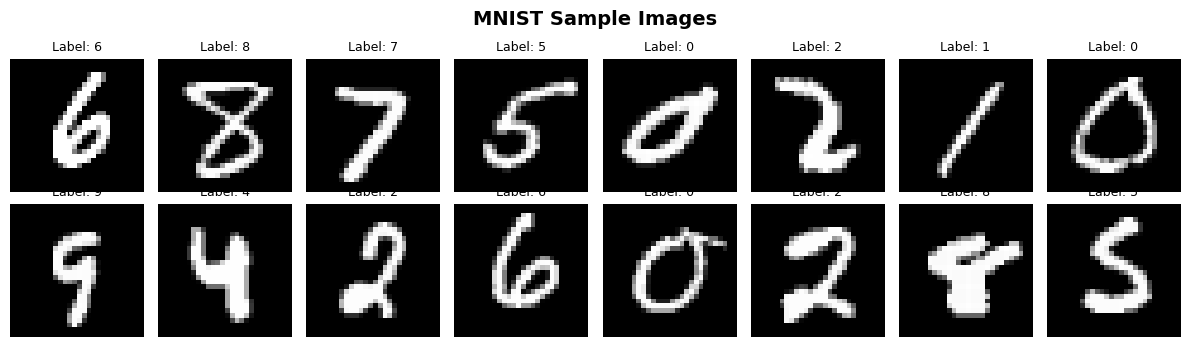

In [55]:
# Visualize MNIST Samples

fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
fig.suptitle('MNIST Sample Images', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    img = images[i].squeeze()      # [1,28,28] -> [28,28]
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Label: {labels[i].item()}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

---
<a id='section-5'></a>
## Section 5 — The Training Loop

The training loop is the **heartbeat of deep learning**. It runs the same 5-step cycle for every batch, repeating for multiple epochs.

```
for each epoch:
    for each batch:
        1. optimizer.zero_grad()  <- Clear old gradients
        2. outputs = model(X)     <- Forward pass
        3. loss = criterion(...)  <- Compute loss
        4. loss.backward()        <- Backpropagation
        5. optimizer.step()       <- Update weights
```

### Why Each Step Matters

| Step | Why it is needed |
|---|---|
| `zero_grad()` | PyTorch accumulates gradients — must reset each step |
| `model(X)` | Runs input through all layers |
| `criterion(...)` | Measures how wrong the predictions are |
| `loss.backward()` | Computes gradient of loss w.r.t. every parameter |
| `optimizer.step()` | Nudges each weight to reduce loss |

### Common Loss Functions & Optimizers

| Task | Loss Function |
|---|---|
| Multi-class classification | `nn.CrossEntropyLoss()` — expects raw logits |
| Binary classification | `nn.BCEWithLogitsLoss()` — more stable than BCE+Sigmoid |
| Regression | `nn.MSELoss()` or `nn.L1Loss()` |

| Optimizer | Notes |
|---|---|
| `optim.Adam(lr=1e-3)` | Best default choice for most tasks |
| `optim.AdamW(lr=1e-3)` | Adam + better weight decay (modern preferred) |
| `optim.SGD(lr=0.01, momentum=0.9)` | Classic, powerful with tuning |

In [56]:
# Setup: MNIST Classifier
torch.manual_seed(42)

mnist_model = nn.Sequential(
    nn.Flatten(),              # [batch,1,28,28] -> [batch,784]
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(mnist_model.parameters(), lr=1e-3, weight_decay=1e-4)

def compute_accuracy(loader, model):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            preds    = model(X_batch).argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total   += y_batch.size(0)
    model.train()
    return correct / total * 100

print('Model and optimizer ready!')

Model and optimizer ready!


In [57]:
# The Training Loop

NUM_EPOCHS = 5
history    = {'train_loss': [], 'train_acc': [], 'val_acc': []}

mnist_model.train()   # Enable Dropout, BatchNorm training behavior

for epoch in range(1, NUM_EPOCHS + 1):
    running_loss = 0.0

    for X_batch, y_batch in mnist_train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        # STEP 1: Zero gradients (prevent accumulation from previous batch)
        optimizer.zero_grad()

        # STEP 2: Forward pass (run input through the model)
        logits = mnist_model(X_batch)           # shape: [64, 10]

        # STEP 3: Compute loss (how wrong are our predictions?)
        loss = criterion(logits, y_batch)

        # STEP 4: Backward pass (compute d(loss)/d(each weight))
        loss.backward()

        # STEP 5: Update weights (gradient descent step)
        optimizer.step()

        running_loss += loss.item()

    avg_loss  = running_loss / len(mnist_train_loader)
    train_acc = compute_accuracy(mnist_train_loader, mnist_model)
    val_acc   = compute_accuracy(mnist_test_loader,  mnist_model)

    history['train_loss'].append(avg_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'Epoch [{epoch}/{NUM_EPOCHS}]  Loss: {avg_loss:.4f}  '
          f'Train Acc: {train_acc:.2f}%  Val Acc: {val_acc:.2f}%')

print('\nTraining complete!')

Epoch [1/5]  Loss: 0.2575  Train Acc: 96.90%  Val Acc: 96.88%
Epoch [2/5]  Loss: 0.1205  Train Acc: 97.81%  Val Acc: 97.30%
Epoch [3/5]  Loss: 0.0890  Train Acc: 98.58%  Val Acc: 97.87%
Epoch [4/5]  Loss: 0.0746  Train Acc: 98.86%  Val Acc: 97.96%


KeyboardInterrupt: 

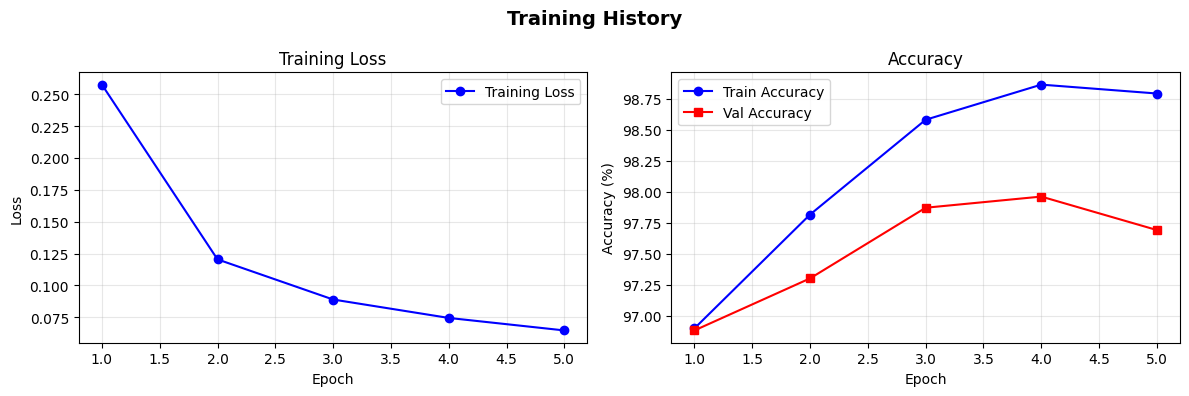

In [ ]:
# Plot Training History

epochs = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

ax1.plot(epochs, history['train_loss'], 'b-o', label='Training Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history['train_acc'], 'b-o', label='Train Accuracy')
ax2.plot(epochs, history['val_acc'],   'r-s', label='Val Accuracy')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
<a id='section-6'></a>
## Section 6 — Saving & Loading Models

### The Correct Way: `state_dict`

A model's `state_dict` is a Python dictionary mapping each layer name to its weight tensor. It is the **recommended way** to save and load models.

```python
# Save
torch.save(model.state_dict(), 'model.pth')

# Load
model = MyModel()    # Recreate the architecture first!
model.load_state_dict(torch.load('model.pth', weights_only=True))
```

### Why NOT save the whole model?
You *can* `torch.save(model, ...)` but it uses Python's `pickle`, which **breaks if you rename the class or move files**. Saving only `state_dict` is more portable.

### Checkpoints
Save the optimizer state too so you can **resume training** exactly where you left off.

In [ ]:
# Saving & Loading: state_dict

SAVE_DIR = './saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

# --- Save weights only ---
weights_path = os.path.join(SAVE_DIR, 'mnist_weights.pth')
torch.save(mnist_model.state_dict(), weights_path)
print(f'Weights saved to: {weights_path}')

# --- Load: recreate architecture, then load weights ---
loaded_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(256, 128), nn.ReLU(),
    nn.Linear(128, 10)
).to(DEVICE)

# weights_only=True is the modern, safe default
state = torch.load(weights_path, map_location=DEVICE, weights_only=True)
loaded_model.load_state_dict(state)
loaded_model.eval()     # Always set eval mode before inference!
print('Model loaded successfully!')

# Verify: outputs should be identical
test_imgs = next(iter(mnist_test_loader))[0][:4].to(DEVICE)
with torch.no_grad():
    orig_out   = mnist_model(test_imgs)
    loaded_out = loaded_model(test_imgs)

print(f'\nOutputs match: {torch.allclose(orig_out, loaded_out)}  <- should be True')

Weights saved to: ./saved_models/mnist_weights.pth
Model loaded successfully!

Outputs match: False  <- should be True


In [ ]:
# Checkpoint: Save optimizer state for training resumption

checkpoint_path = os.path.join(SAVE_DIR, 'checkpoint_epoch5.pth')

checkpoint = {
    'epoch':           NUM_EPOCHS,
    'model_state':     mnist_model.state_dict(),
    'optimizer_state': optimizer.state_dict(),
    'train_loss':      history['train_loss'][-1],
    'val_acc':         history['val_acc'][-1],
}
torch.save(checkpoint, checkpoint_path)
print(f'Checkpoint saved to: {checkpoint_path}')

# --- Loading a checkpoint to resume training ---
ckpt = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)

resume_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(256, 128), nn.ReLU(),
    nn.Linear(128, 10)
).to(DEVICE)
resume_optimizer = optim.AdamW(resume_model.parameters(), lr=1e-3)

resume_model.load_state_dict(ckpt['model_state'])
resume_optimizer.load_state_dict(ckpt['optimizer_state'])
start_epoch = ckpt['epoch'] + 1

print(f'Resumed from epoch  : {ckpt["epoch"]}')
print(f'Last val accuracy   : {ckpt["val_acc"]:.2f}%')
print(f'Next epoch would be : {start_epoch}')

Checkpoint saved to: ./saved_models/checkpoint_epoch5.pth
Resumed from epoch  : 5
Last val accuracy   : 97.69%
Next epoch would be : 6


In [ ]:
# state_dict Deep Dive: inspect layer names and shapes

state = mnist_model.state_dict()
print(f'Keys in state_dict ({len(state)} total):\n')
print(f"{'Key':<30} {'Shape':<25} {'Dtype':<12}")
print('-' * 70)
for key, tensor in state.items():
    print(f'{key:<30} {str(list(tensor.shape)):<25} {str(tensor.dtype):<12}')

Keys in state_dict (6 total):

Key                            Shape                     Dtype       
----------------------------------------------------------------------
1.weight                       [256, 784]                torch.float32
1.bias                         [256]                     torch.float32
4.weight                       [128, 256]                torch.float32
4.bias                         [128]                     torch.float32
6.weight                       [10, 128]                 torch.float32
6.bias                         [10]                      torch.float32


---
<a id='section-7'></a>
## Section 7 — CPU vs GPU Device Management

### The Two Hardware Accelerators

| Device | Access | Best For |
|---|---|---|
| **CPU** | Always available | Small models, debugging, NumPy interop |
| **CUDA** (NVIDIA GPU) | `torch.cuda.is_available()` | Large models, fast parallel training |
| **MPS** (Apple Silicon) | `torch.backends.mps.is_available()` | Mac M1/M2/M3 acceleration |

### The Device Pattern

Always write **device-agnostic code** — code that works on any hardware:

```python
DEVICE = (
    torch.device('cuda') if torch.cuda.is_available()
    else torch.device('mps') if torch.backends.mps.is_available()
    else torch.device('cpu')
)

model = MyModel().to(DEVICE)    # move model
X     = X.to(DEVICE)           # move data
```

In [ ]:
# Device Information Summary

def print_device_info():
    print('=' * 55)
    print('  DEVICE SUMMARY')
    print('=' * 55)
    print(f'  CPU  : {platform.processor() or platform.machine()}')

    if torch.cuda.is_available():
        for i in range(torch.cuda.device_count()):
            name = torch.cuda.get_device_name(i)
            mem  = torch.cuda.get_device_properties(i).total_memory / 1e9
            print(f'  CUDA : {name} ({mem:.1f} GB VRAM)')
    else:
        print('  CUDA : Not available')

    if torch.backends.mps.is_available():
        print('  MPS  : Apple Silicon GPU - Available')
    elif torch.backends.mps.is_built():
        print('  MPS  : Built but not available (macOS < 12.3?)')
    else:
        print('  MPS  : Not available')

    print('-' * 55)
    print(f'  Active Device: {DEVICE}')
    print('=' * 55)

print_device_info()

  DEVICE SUMMARY
  CPU  : arm
  CUDA : Not available
  MPS  : Apple Silicon GPU - Available
-------------------------------------------------------
  Active Device: mps


In [ ]:
# Moving Models & Tensors to Devices

small_net = nn.Sequential(nn.Linear(10, 5), nn.ReLU(), nn.Linear(5, 2))
print(f'Model device (before): {next(small_net.parameters()).device}')

small_net = small_net.to(DEVICE)
print(f'Model device (after) : {next(small_net.parameters()).device}')

# Tensor movement
t = torch.randn(3, 10)
print(f'\nTensor starts on : {t.device}')

t_device = t.to(DEVICE)
print(f'After .to(DEVICE): {t_device.device}')

# Run inference on device
with torch.no_grad():
    output = small_net(t_device)
print(f'\nInference output device : {output.device}')
print(f'Inference output shape  : {output.shape}')

Model device (before): cpu
Model device (after) : mps:0

Tensor starts on : cpu
After .to(DEVICE): mps:0

Inference output device : mps:0
Inference output shape  : torch.Size([3, 2])


In [ ]:
# Training Mode vs Eval Mode
#
# Dropout and BatchNorm behave DIFFERENTLY in train vs eval mode!
#   - Dropout: active (drops neurons) in train, disabled in eval
#   - BatchNorm: uses batch stats in train, running stats in eval

net = nn.Sequential(nn.Linear(10, 10), nn.Dropout(p=0.5))
x   = torch.ones(1, 10)

net.train()                         # Training mode: dropout active
out_train = net(x)
print(f'Train mode output: {out_train.detach().round()}')

net.eval()                          # Eval mode: dropout disabled
with torch.no_grad():
    out_eval = net(x)
print(f'Eval mode output : {out_eval.detach().round()}')

print('\n' + '=' * 50)
print('  model.train()  -> before training loop')
print('  model.eval()   -> before inference/validation')
print('=' * 50)

Train mode output: tensor([[ 1.,  1.,  0., -0., -1.,  0.,  0.,  0.,  3.,  1.]])
Eval mode output : tensor([[ 1.,  1.,  0., -0., -1.,  0.,  0.,  0.,  1.,  0.]])

  model.train()  -> before training loop
  model.eval()   -> before inference/validation


In [ ]:
# Performance Benchmark: CPU vs Active Device

SIZE = 2048
REPS = 20

def benchmark(device):
    a = torch.randn(SIZE, SIZE, device=device)
    b = torch.randn(SIZE, SIZE, device=device)
    for _ in range(3):            # warmup
        _ = a @ b
    start = time.perf_counter()
    for _ in range(REPS):
        c = a @ b
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return (time.perf_counter() - start) / REPS * 1000

cpu_ms = benchmark(torch.device('cpu'))
print(f'CPU  : {cpu_ms:.2f} ms per {SIZE}x{SIZE} matmul')

if DEVICE.type != 'cpu':
    gpu_ms = benchmark(DEVICE)
    print(f'{str(DEVICE).upper():<5}: {gpu_ms:.2f} ms per {SIZE}x{SIZE} matmul')
    print(f'\nSpeedup: {cpu_ms / gpu_ms:.1f}x faster on {DEVICE}')
else:
    print('\nNo GPU/MPS available. Running on CPU only.')

CPU  : 12.70 ms per 2048x2048 matmul
MPS  : 0.04 ms per 2048x2048 matmul

Speedup: 358.1x faster on mps
